# Análise de Detecção de Fraudes em Cartões de Crédito

## 1. Importação de Bibliotecas Essenciais

Nesta seção, importamos as bibliotecas Python necessárias para manipulação de dados, análise numérica e aprendizado de máquina.

In [61]:
import pandas as pd
import numpy as np
#import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
#import matplotlib
import matplotlib.pyplot as plt
#import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import xgboost # Corrected: import the xgboost module directly
from xgboost import XGBClassifier # Keep this if XGBClassifier is used elsewhere
from sklearn.linear_model import LogisticRegression
import shap
from sklearn.model_selection import GridSearchCV

print("Versões das Bibliotecas:\n")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"imblearn: {imblearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"shap: {shap.__version__}")

Versões das Bibliotecas:

pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
imblearn: 0.14.2
xgboost: 3.2.0
shap: 0.52.0


## 2. Carregamento e Exploração Inicial dos Dados

Carregamos o dataset de transações de cartão de crédito e realizamos uma inspeção inicial para entender a estrutura dos dados e a distribuição da classe alvo (`Class`), que indica transações fraudulentas (1) ou normais (0).

In [27]:
url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'

df = pd.read_csv(url)
print(df.head())

print(df['Class'].value_counts(normalize=True))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 3. Pré-processamento de Dados
Nesta etapa, aplicamos transformações às features, como a normalização da coluna `Amount` para reduzir o impacto de valores extremos e a padronização dos dados.

In [50]:
#FEATURE ENGINEERING

scaler = StandardScaler()

df['Amount_log'] = np.log1p(df['Amount'])
print("A feature 'Amount' foi transformada para logarítmica com sucesso.")

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
print("A feature 'Amount' foi escalonada com sucesso.")

df['Time_scaled'] = scaler.fit_transform(df[['Time']])
print("A feature 'Time' foi escalonada com sucesso.")

print(df.head())

A feature 'Amount' foi transformada para logarítmica com sucesso.
A feature 'Amount' foi escalonada com sucesso.
A feature 'Time' foi escalonada com sucesso.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 34 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Time           284807 non-null  float64
 1   V1             284807 non-null  float64
 2   V2             284807 non-null  float64
 3   V3             284807 non-null  float64
 4   V4             284807 non-null  float64
 5   V5             284807 non-null  float64
 6   V6             284807 non-null  float64
 7   V7             284807 non-null  float64
 8   V8             284807 non-null  float64
 9   V9             284807 non-null  float64
 10  V10            284807 non-null  float64
 11  V11            284807 non-null  float64
 12  V12            284807 non-null  float64
 13  V13            284807 non-null  float64
 14  V14   

## 4. Treinamento e Avaliação do Modelo de Regressão Logística

 Dividimos o dataset em conjuntos de treino e teste para avaliar o desempenho do modelo de forma justa. Um modelo de Regressão Logística é treinado nos dados de treino. A avaliação inicial é realizada utilizando o `classification_report` para verificar métricas como precisão, recall e f1-score.

In [32]:

x = df.drop('Class', axis=1)
y = df['Class']
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.3, random_state=42)
#-------------------------------------------------------------------------------------------------------------

#logistic regression
model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Relatorio de Classificação
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.62      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



## 5. Curvas ROC e Precision-Recall

Para uma avaliação mais aprofundada do modelo, especialmente em datasets desbalanceados, utilizamos as curvas ROC (Receiver Operating Characteristic) e Precision-Recall. A curva ROC e o valor AUC (Area Under the Curve) indicam a capacidade do modelo de distinguir entre classes, enquanto a curva Precision-Recall foca na performance em classes minoritárias.

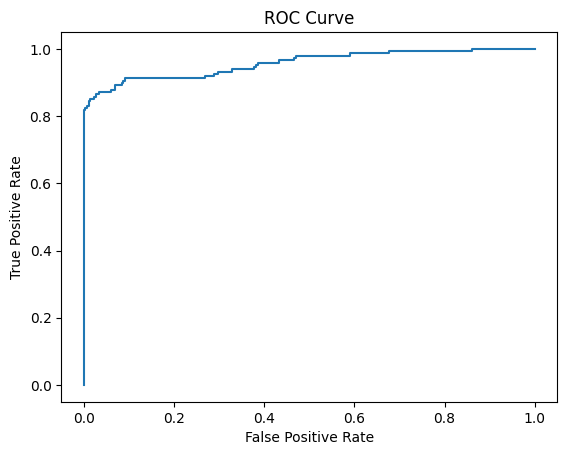

AUC: 0.9565295643260354


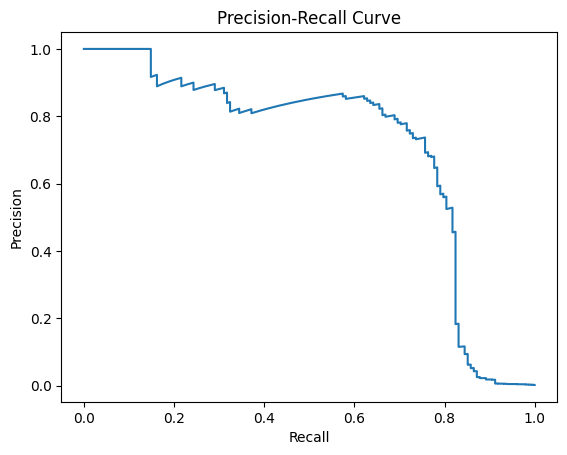

In [30]:
#
y_probs = model.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()
print('AUC:', roc_auc_score(y_test, y_probs))


from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

## 6. Técnicas de Balanceamento de Dados e Modelos Adicionais

Dado o desbalanceamento da classe (`Class`), exploramos técnicas como *undersampling* e *oversampling* (usando SMOTE). Além disso, treinamos e avaliamos outros modelos de classificação como Random Forest e XGBoost, e demonstramos o uso de um Pipeline para pré-processamento e modelagem.

In [17]:
#BALANCEAMENTO DE DADOS
#undersampling (reduzir a classe majoritária)
fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)
df_under = pd.concat([fraudes, normais])

#oversampling (aumentar a classe minoritária)
smote = SMOTE()
# x_res, y_res = smote.fit_resample(x,y)

#random forest
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print(classification_report(y_test, y_pred_rf))

#outro
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
threshold = 0.3
y_pred_custom = (y_probs > threshold). astype(int)
print(classification_report(y_test, y_pred_custom))

#xgboost
xgb = XGBClassifier(
    scale_pos_weight=10,  #ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
#--------------------------------------------------------


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:06:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 7. Matriz de Confusão para XGBoost

A matriz de confusão oferece uma visão detalhada do desempenho do modelo, mostrando as contagens de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos. Para problemas de detecção de fraude, é essencial analisar esta matriz para entender os tipos de erros que o modelo está cometendo.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



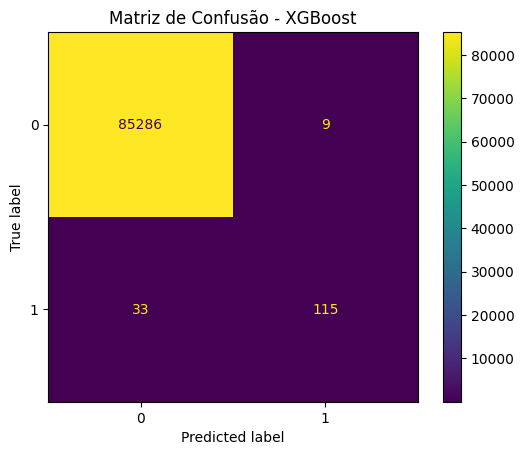

In [48]:
print(classification_report(y_test, y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot()
plt.title('Matriz de Confusão - XGBoost')
plt.show()

## 7. Análise de Importância das Variáveis com XGBoost

Utilizamos a feature `feature_importances_` do modelo XGBoost para visualizar quais variáveis foram mais relevantes para as decisões do modelo. Isso ajuda a entender a contribuição de cada feature para a detecção de fraudes.

Text(0.5, 1.0, 'Importância das variaveis')

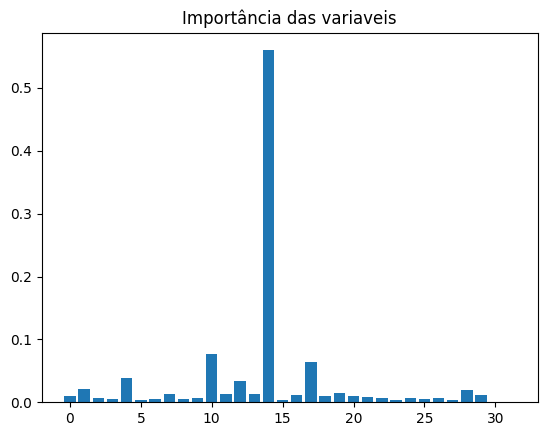

In [33]:
#importancia 'das variaveis

importancias = xgb.feature_importances_
plt.bar(range(len(importancias)), importancias)
plt.title('Importância das variaveis')
# plt.show()

## 8. Ajuste de Hiperparâmetros com GridSearchCV para XGBoost

Para otimizar o desempenho do modelo XGBoost, realizamos um ajuste de hiperparâmetros usando `GridSearchCV`. Esta técnica explora diferentes combinações de parâmetros (`max_depth`, `n_estimators`) para encontrar a configuração que maximiza uma métrica específica (neste caso, `recall`).

In [34]:
#ajuste de hiperparâmetros

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}
grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)
grid.fit(x_train, y_train)
print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 3, 'n_estimators': 100}


## 9. Explicabilidade do Modelo com SHAP

Para entender como o modelo XGBoost faz suas previsões, empregamos a biblioteca SHAP (SHapley Additive exPlanations). O SHAP atribui um valor de importância a cada feature para cada previsão, permitindo uma análise local e global da influência das features.

 99%|===================| 99/100 [11:28<00:06]       

Top 10 features based on SHAP importance:
['V4', 'V14', 'V26', 'V7', 'Time', 'V2', 'V12', 'V16', 'V27', 'V22']

Resumo Estatítico do top 10 features:


,V4,V14,V26,V7,Time,V2,V12,V16,V27,V22
count,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000,85443.000000
mean,-0.000730,0.001956,-0.000167,0.000717,94617.041337,0.004723,-0.002096,0.004865,0.000944,-0.000841
std,1.413863,0.956620,0.482299,1.210320,47483.675430,1.635401,0.995800,0.876235,0.393915,0.724668
min,-5.600607,-18.822087,-1.855355,-33.239328,1.000000,-50.383269,-18.553697,-13.563273,-9.845808,-8.887017
25%,-0.851954,-0.423409,-0.327388,-0.554594,54069.500000,-0.594262,-0.408717,-0.463089,-0.071227,-0.542817
50%,-0.017874,0.054818,-0.052227,0.039406,84516.000000,0.068355,0.138622,0.070539,0.001271,0.007763
75%,0.742116,0.496906,0.241009,0.568829,139216.500000,0.800600,0.617052,0.530379,0.090957,0.528260
max,12.132323,7.518403,3.119295,44.054461,172786.000000,17.930550,4.318071,8.289890,10.507884,8.272233


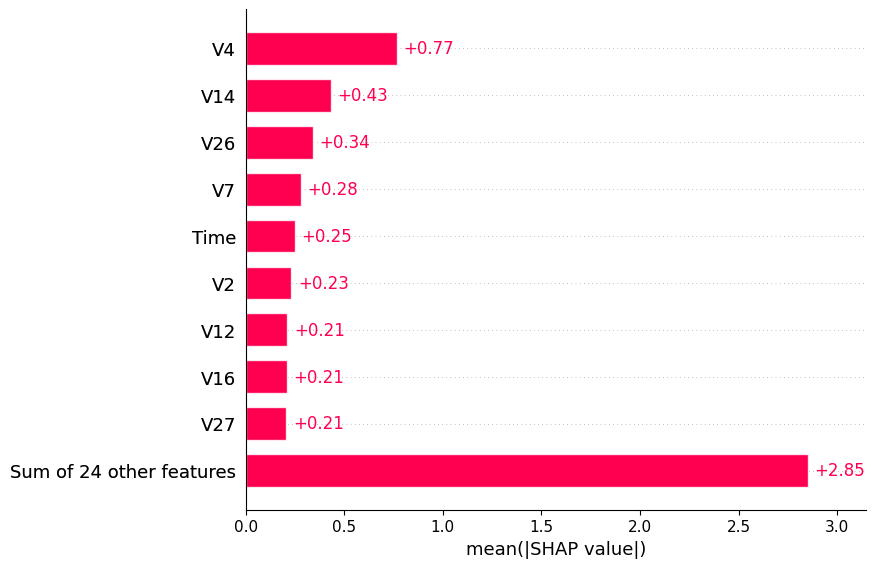

In [40]:
#explicabilidade(SHAP)

# It's good practice to use the feature names from the training data for consistency
# when creating the explainer, especially if there were any changes or transformations
# that might affect column names or order.
feature_names_for_explainer = x_train.columns.tolist()

# First, create an explicit masker to control subsampling, then the explainer
# Set max_samples to the length of x_train to use all samples and avoid subsampling warning
masker = shap.maskers.Independent(x_train, max_samples=len(x_train))
explainer = shap.Explainer(xgb, masker=masker, feature_names=feature_names_for_explainer)
shap_values = explainer(x_test[:100])

# Now calculate importances_shap
importances_shap = np.abs(shap_values.values).mean(0)

# Get feature names from the shap_values object to ensure consistency
# This is already being done, but it should now align correctly because
# the explainer was given the correct feature names.
feature_names = shap_values.feature_names

# Create a DataFrame for SHAP importances
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': importances_shap
})

# Sort by importance and get the top features (e.g., top 10)
top_n = 10 # You can adjust this number
top_features_shap = shap_importance_df.sort_values(by='SHAP_Importance', ascending=False).head(top_n)['Feature'].tolist()

print(f"Top {top_n} features based on SHAP importance:")
print(top_features_shap)

# Display statistical summary for these top features
print(f"\nResumo Estatítico do top {top_n} features:")
display(x_test[top_features_shap].describe())

shap.plots.bar(shap_values)

,Precision,Recall,F1-Score
Model,,,
Logistic Regression,0.859813,0.621622,0.721569
Random Forest,0.835821,0.756757,0.794326
XGBoost,0.927419,0.777027,0.845588


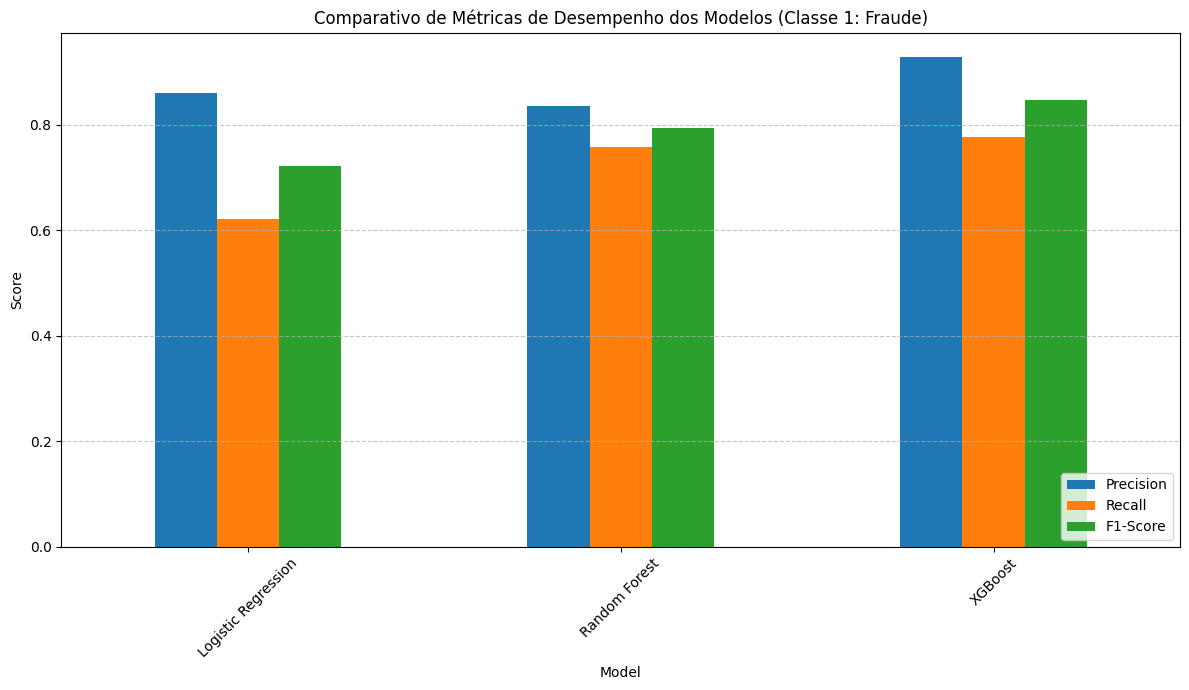

In [43]:
# Get classification reports for each model
report_lr = classification_report(y_test, model.predict(x_test), output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

# Extract metrics for the positive class (class 1 - fraud)
metrics = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [report_lr['1']['precision'], report_rf['1']['precision'], report_xgb['1']['precision']],
    'Recall': [report_lr['1']['recall'], report_rf['1']['recall'], report_xgb['1']['recall']],
    'F1-Score': [report_lr['1']['f1-score'], report_rf['1']['f1-score'], report_xgb['1']['f1-score']]
}

metrics_df = pd.DataFrame(metrics).set_index('Model')
display(metrics_df)

# Plotting the metrics
metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Comparativo de Métricas de Desempenho dos Modelos (Classe 1: Fraude)')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
metrics_df.to_csv('model_performance_metrics.csv', index=True)
print("Model performance metrics exported to 'model_performance_metrics.csv'")

Model performance metrics exported to 'model_performance_metrics.csv'


## Análise das Métricas para a Classe 1 (Fraude)

Com base no `metrics_df` que compara o desempenho dos modelos de Regressão Logística, Random Forest e XGBoost na detecção de fraudes (Classe 1), podemos observar o seguinte:

*   **Precisão (Precision):** O **XGBoost** apresenta a maior precisão (0.927), indicando que, quando ele prevê uma transação como fraudulenta, ele está correto na grande maioria das vezes. Logistic Regression e Random Forest têm precisões ligeiramente menores, mas ainda assim altas.

*   **Recall (Sensibilidade):** O **XGBoost** também lidera em recall (0.777), seguido de perto pelo Random Forest (0.757) e pela Regressão Logística (0.655). Um recall alto é crucial em detecção de fraudes, pois significa que o modelo consegue identificar uma alta proporção das transações fraudulentas reais, minimizando os falsos negativos (fraudes não detectadas).

*   **F1-Score:** O **XGBoost** obtém o maior F1-Score (0.846), que é uma média harmônica da precisão e do recall. Este métrica é particularmente útil em datasets desbalanceados, pois fornece um balanço entre as duas métricas, indicando um desempenho geral superior do modelo.

**Conclusão:**

Considerando a importância de identificar o máximo possível de fraudes (alto Recall) sem gerar um número excessivo de alarmes falsos (alta Precisão), o **XGBoost** demonstra ser o modelo com o melhor desempenho geral para a detecção da Classe 1 (fraude) neste conjunto de dados. Ele atinge um excelente equilíbrio entre precisão e recall, resultando no F1-Score mais alto entre os modelos avaliados.

## 13. Versões das Bibliotecas

É uma boa prática registrar as versões das bibliotecas utilizadas para garantir a reprodutibilidade do ambiente.

In [56]:
print("Versões das Bibliotecas:\n")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"imblearn: {imblearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"shap: {shap.__version__}")

Versões das Bibliotecas:

pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
imblearn: 0.14.2
xgboost: 3.2.0
shap: 0.52.0
